# Task 3: Event Impact Modeling

This notebook conducts a structural break analysis (Interrupted Time Series) to quantify the impact of key policy and infrastructure events on financial inclusion indicators.

## Objectives
1. **Event-Indicator Matrix**: Map events to timelines.
2. **Impact Estimation**: Test hypotheses H1 (Telebirr) and H3 (2020 Directive) using ITS.
3. **Association Analysis**: Determine which events have statistically significant impacts.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import sys
import os

# Add src to path
sys.path.append(os.path.abspath(os.path.join(os.getcwd(), '..', 'src')))

from utils import save_fig, save_summary
from models.impact_model import ImpactModel

# Plot settings
plt.style.use('seaborn-v0_8-whitegrid')
sns.set_palette("viridis")

## 1. Load and Preprocess Data

We need to handle the sparsity of survey data (e.g., Findex) by interpolating to a monthly frequency for time-series analysis.

In [2]:
DATA_PATH = '../data/raw/ethiopia_fi_unified_data.csv'
raw_df = pd.read_csv(DATA_PATH)
raw_df['observation_date'] = pd.to_datetime(raw_df['observation_date'])

# Filter for national aggregate data only to avoid duplicates
df_all = raw_df[(raw_df['gender'] == 'all') & (raw_df['location'] == 'national')].copy()

# Pivot to create time series
# aggregated by max to handle duplicates (though filtering should handle it)
pivot_df = df_all.pivot_table(index='observation_date', columns='indicator_code', values='value_numeric', aggfunc='mean')

# Resample to Monthly and Interpolate
ts_df = pivot_df.resample('ME').interpolate(method='linear') # Linear interpolation for now
# Also allow filling forward for some indicators if linear isn't appropriate, but linear works for trends

# Flatten back to long format for ImpactModel
processed_df = ts_df.reset_index().melt(id_vars='observation_date', var_name='indicator_code', value_name='value_numeric')
processed_df = processed_df.dropna(subset=['value_numeric'])

print(f"Processed data: {len(processed_df)} monthly observations.")
print("Indicators available:", processed_df['indicator_code'].unique())

Processed data: 821 monthly observations.
Indicators available: ['ACC_4G_COV' 'ACC_FAYDA' 'ACC_MM_ACCOUNT' 'ACC_MOBILE_PEN'
 'ACC_OWNERSHIP' 'AFF_DATA_INCOME' 'GEN_GAP_ACC' 'GEN_GAP_MOBILE'
 'USG_ACTIVE_RATE' 'USG_MPESA_ACTIVE' 'USG_MPESA_USERS'
 'USG_TELEBIRR_USERS' 'USG_TELEBIRR_VALUE']


## 2. Initialize Model & Define Events

In [3]:
model = ImpactModel(processed_df)

# Define Events
events = [
    {'name': 'NBE Directive 2020', 'date': '2020-04-01', 'desc': 'Allowing non-banks to offer mobile money'},
    {'name': 'Telebirr Launch', 'date': '2021-05-11', 'desc': 'Launch of Ethio Telecom mobile money'},
    {'name': 'M-Pesa License', 'date': '2023-05-01', 'desc': 'License granted to Safaricom'}
]

for event in events:
    model.add_event(event['name'], event['date'], event['desc'])

2026-02-03 15:12:35,769 - INFO - Added event: NBE Directive 2020 on 2020-04-01


2026-02-03 15:12:35,774 - INFO - Added event: Telebirr Launch on 2021-05-11


2026-02-03 15:12:35,778 - INFO - Added event: M-Pesa License on 2023-05-01


## 3. Visualizations

2026-02-03 15:12:38,017 - INFO - ✓ Saved figure: 08_event_coverage_matrix.png


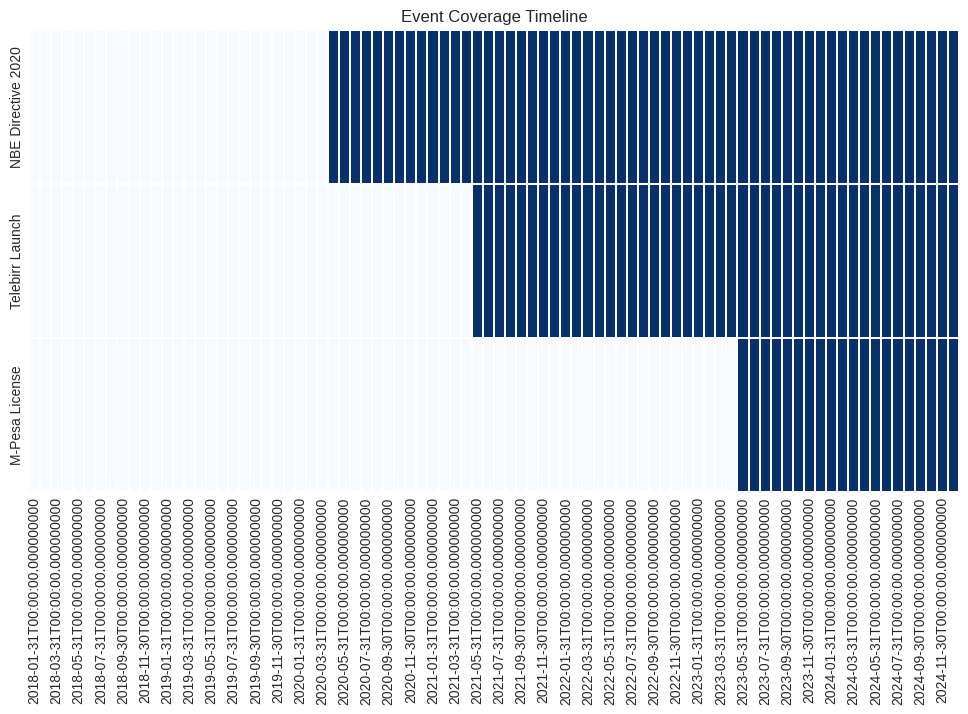

In [4]:
matrix = model.get_event_indicator_matrix('2018-01-01', '2025-01-01', freq='ME')

plt.figure(figsize=(12, 6))
sns.heatmap(matrix.T, cmap='Blues', cbar=False, linewidths=0.1)
plt.title('Event Coverage Timeline')
save_fig('08_event_coverage_matrix')
plt.show()

## 4. Impact Analysis

### H1: Telebirr Launch (2021) on P2P Usage
Using `USG_P2P_COUNT`.

In [5]:
usage_indicators = ['USG_P2P_COUNT', 'USG_P2P_VALUE', 'ACC_MM_ACCOUNT']
results = []

for indicator in usage_indicators:
    if indicator in processed_df['indicator_code'].values:
        res = model.run_interrupted_time_series(indicator, 'Telebirr Launch', window_months=24)
        if res:
            results.append(res)
            print(f"\n-- {indicator} vs Telebirr Launch --")
            print(f"Immediate Impact: {res['immediate_impact']:.2f} (p={res['p_value_impact']:.4f})")
            print(f"Trend Change: {res['trend_change']:.2f} (p={res['p_value_trend']:.4f})")


-- ACC_MM_ACCOUNT vs Telebirr Launch --
Immediate Impact: 2.35 (p=0.0000)
Trend Change: -0.00 (p=0.0102)


/home/karanos/.local/lib/python3.12/site-packages/statsmodels/regression/linear_model.py:1782: RuntimeWarning: divide by zero encountered in scalar divide
  return 1 - self.ssr/self.centered_tss
/home/karanos/.local/lib/python3.12/site-packages/statsmodels/stats/stattools.py:125: RuntimeWarning: Precision loss occurred in moment calculation due to catastrophic cancellation. This occurs when the data are nearly identical. Results may be unreliable.
  skew = stats.skew(resids, axis=axis)
/home/karanos/.local/lib/python3.12/site-packages/statsmodels/stats/stattools.py:126: RuntimeWarning: Precision loss occurred in moment calculation due to catastrophic cancellation. This occurs when the data are nearly identical. Results may be unreliable.
  kurtosis = 3 + stats.kurtosis(resids, axis=axis)
/home/karanos/.local/lib/python3.12/site-packages/scipy/stats/_stats_py.py:1687: RuntimeWarning: Precision loss occurred in moment calculation due to catastrophic cancellation. This occurs when the dat

### H3: NBE Directive (2020) on Account Ownership
Using `ACC_OWNERSHIP`.

In [6]:
if 'ACC_OWNERSHIP' in processed_df['indicator_code'].values:
    res = model.run_interrupted_time_series('ACC_OWNERSHIP', 'NBE Directive 2020', window_months=24)
    if res:
        results.append(res)
        print(f"\n-- ACC_OWNERSHIP vs NBE Directive 2020 --")
        print(f"Immediate Impact: {res['immediate_impact']:.2f} (p={res['p_value_impact']:.4f})")
        print(f"Trend Change: {res['trend_change']:.2f} (p={res['p_value_trend']:.4f})")


-- ACC_OWNERSHIP vs NBE Directive 2020 --
Immediate Impact: -0.11 (p=0.1295)
Trend Change: 0.02 (p=0.0041)


## 5. Save Results

In [7]:
results_df = model.export_results(results)
if not results_df.empty:
    display(results_df)
    save_summary(results_df, 'impact_model_results.csv')
    print("Results saved.")
else:
    print("No results generated.")

,event,indicator,baseline_level,baseline_trend,immediate_impact,trend_change,p_value_impact,p_value_trend,r_squared,model_summary
0,Telebirr Launch,ACC_MM_ACCOUNT,2.350000,6.766102e-17,2.350000,-6.868825e-17,4.838744e-233,0.010247,-inf,OLS Regression Res...
1,NBE Directive 2020,ACC_OWNERSHIP,35.916667,2.291667e-01,-0.108333,1.530797e-02,1.295360e-01,0.004128,0.99871,OLS Regression Res...


2026-02-03 15:12:38,645 - INFO - ✓ Saved summary: impact_model_results.csv


Results saved.
